## Exploratory Data Analysis

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway
from tabulate import tabulate

## Chi-Square Test and ANOVA Test

In [ ]:

df = pd.read_csv("dataset.csv")

y = df ["y"]

cat_cols = ("job", "marital", "education", "default", "housing", "loan", "contact", "month")
d = {}

def chi2_pval(c):
    ct = pd.crosstab(df[c], y)
    stat, p, dof, expected = chi2_contingency(ct)
    return p

for col in cat_cols:
    d[col] = chi2_pval(col)

table = d.items()
print("Chi-square p-values:")
print(tabulate(table, headers=["Variable", "p-value"]))


num_cols = ("age", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed")
d = {}

def anova_pval(c):
    group_0 = df[df["y"] == 0][c]
    group_1 = df[df["y"] == 1][c]
    stat, p = f_oneway(group_0, group_1)
    return p

for col in num_cols:
    d[col] = anova_pval(col)

table = d.items()
print("\nANOVA p-values:")
print(tabulate(table, headers=["Variable", "p-value"]))


Chi-square p-values:
Variable         p-value
----------  ------------
job         4.18976e-199
marital     2.06801e-26
education   3.30519e-38
default     5.16196e-89
housing     0.0582945
loan        0.578675
contact     1.52599e-189
month       0

ANOVA p-values:
Variable             p-value
--------------  ------------
age             6.80214e-10
campaign        2.00778e-41
pdays           0
previous        0
emp.var.rate    0
cons.price.idx  9.31896e-170
cons.conf.idx   7.53666e-29
euribor3m       0
nr.employed     0


## Exploring Categorical Variables using Countplot

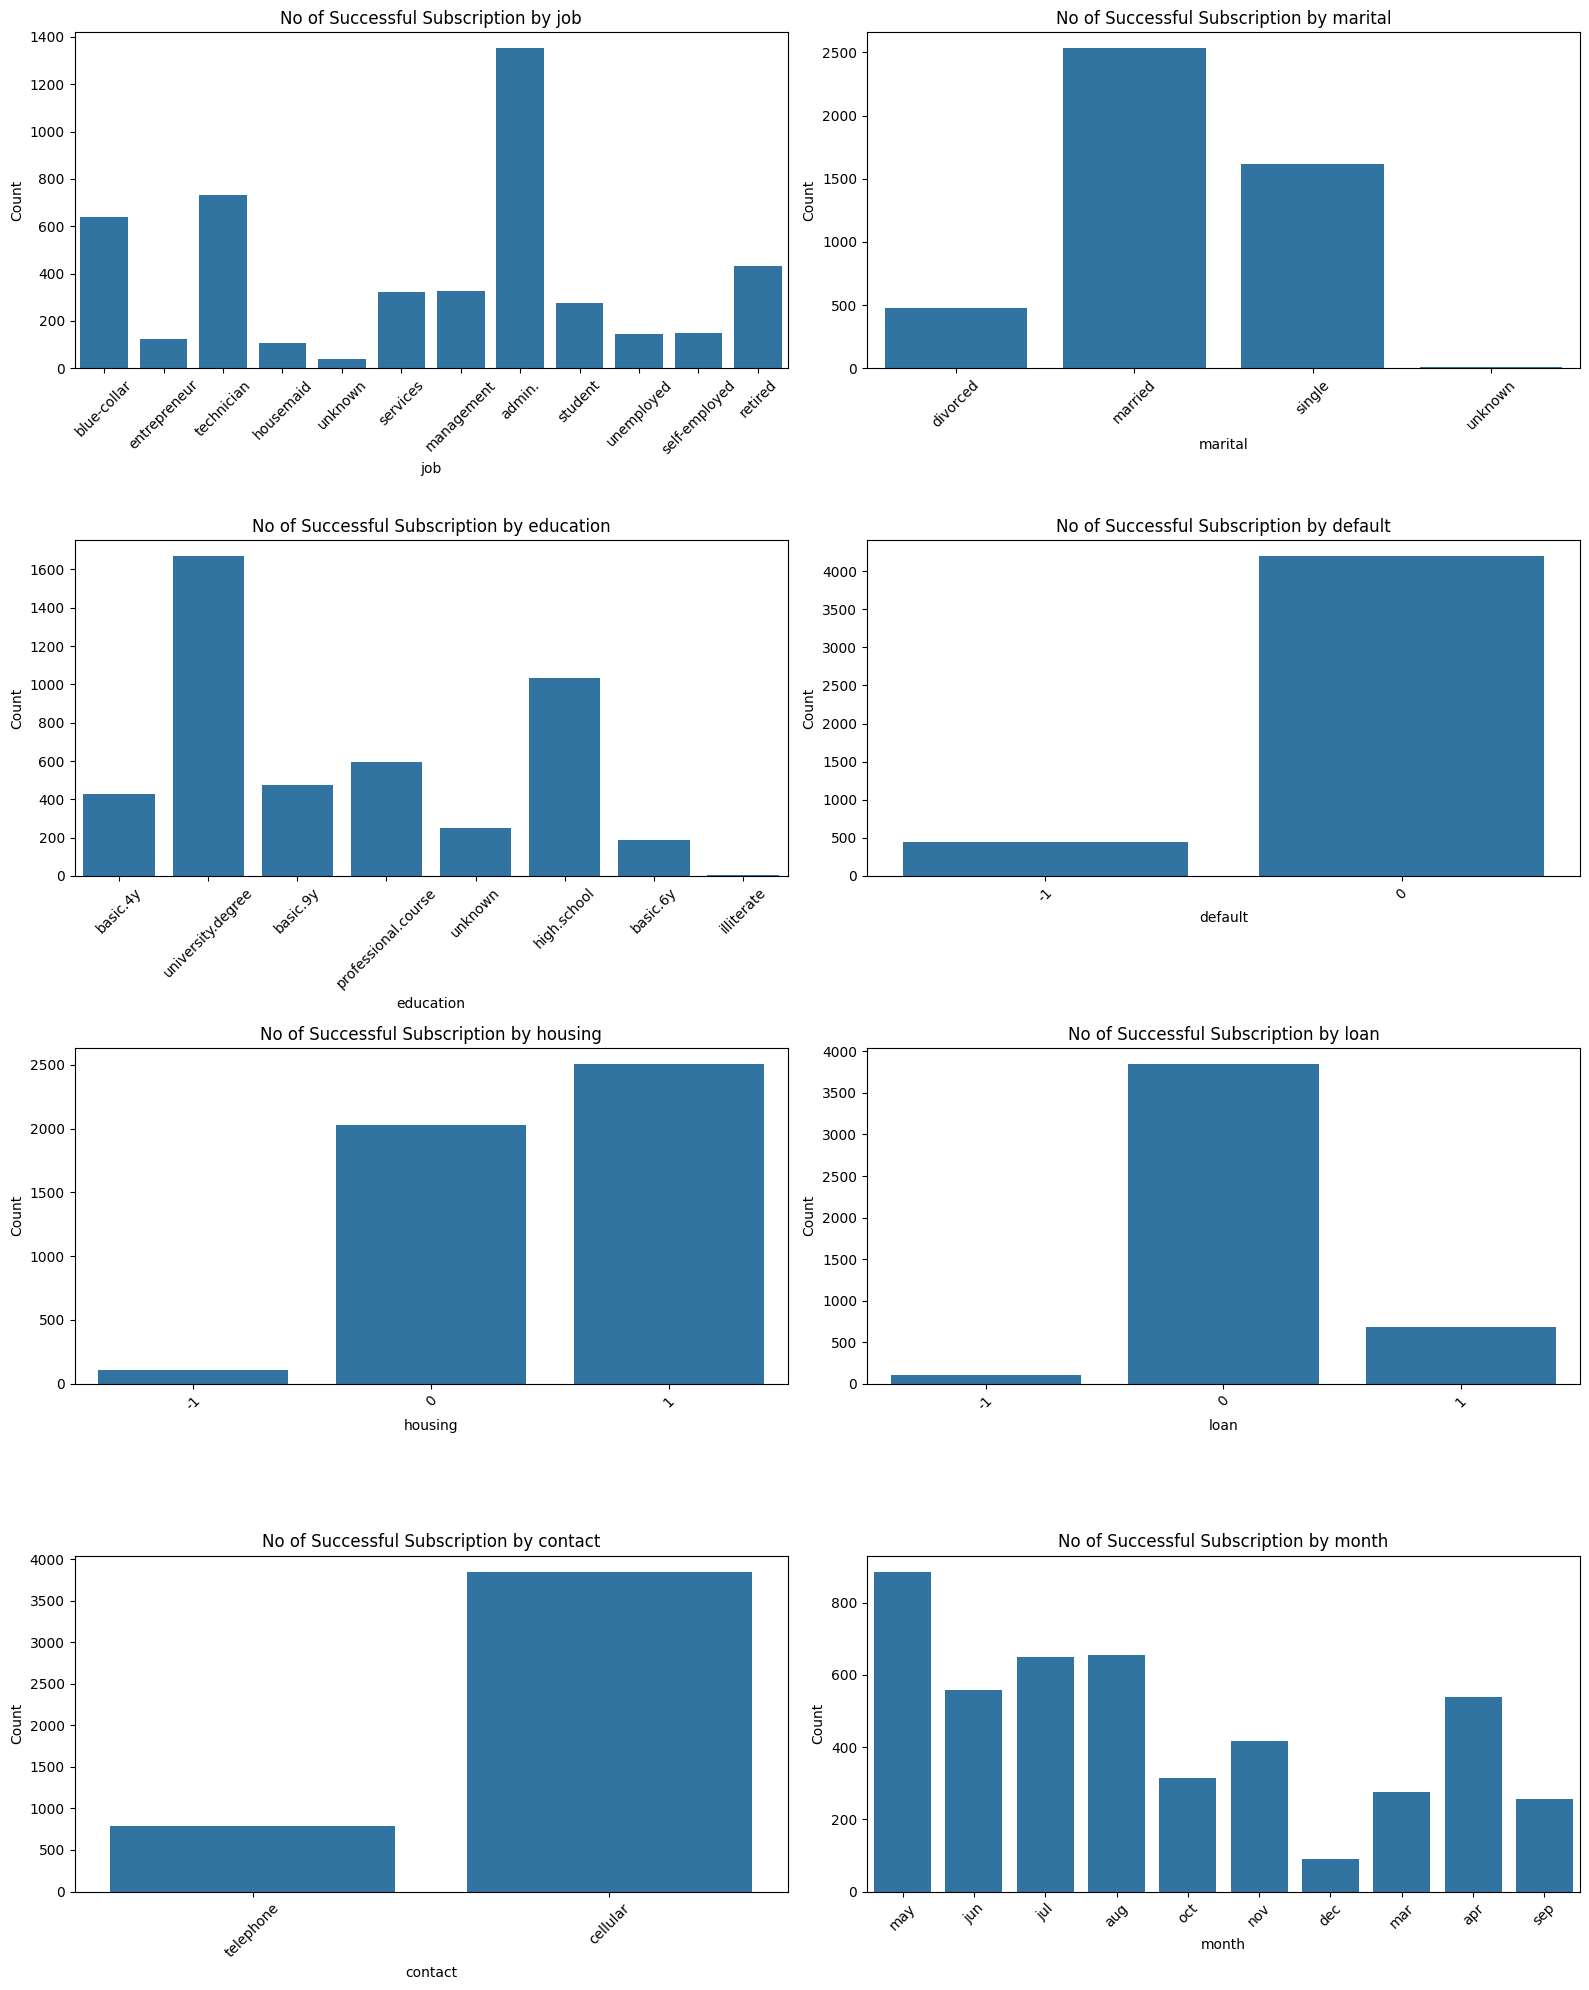

In [30]:
categorical_cols = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'month'
]

df_yes = df[df['y'] == 1] 

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df_yes, x=col, ax=axes[i])
    axes[i].set_title(f'No of Successful Subscription by {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Based on the above plots, the following was deduced from each category:
- For jobs, The largest number of successful subscriptions comes from admin, followed by technician and blue-collar.
- For marital status, the largest number of successful susbcriptions came from marital, followed by divorce and single.
- For education, the largest number of successful subscriptions came from those with a university degree, followed by high school. 
- Almost all subscription came from those without default. However, data might be skewed as the presence of those with default is not present.
- For housing, there is a moderate difference between the number of successful subscriptions between those with and without hosuing
- For loan, most of the successful subscription came from those without a loan
- For contact, most of the successful subscription came from those with a cellular handphone
- For month, the months with the most successes was in May, followed by July and August


Although some categories appear to have a large number of successful subscriptions, this may partly reflect the fact that these groups make up a larger share of the overall dataset.

## Exploration of numerical variables using Correlation Heatmap

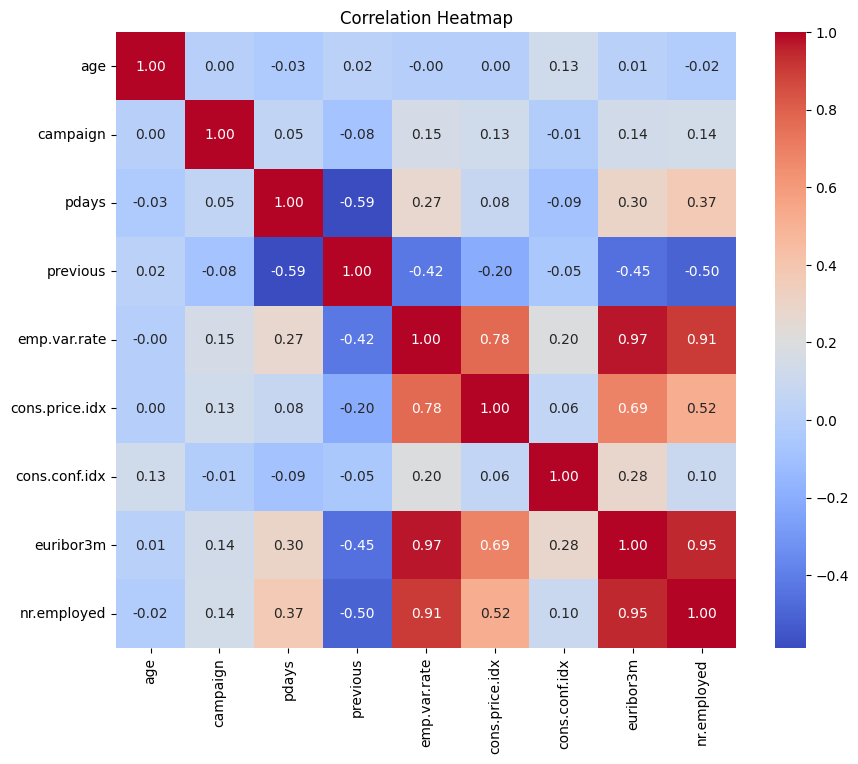

In [ ]:
numeric_cols = [
    'age', 'campaign', 'pdays', 'previous',
    'emp.var.rate', 'cons.price.idx',
    'cons.conf.idx', 'euribor3m', 'nr.employed'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

The correlation heatmap shows that several socioeconomic variables, particularly emp.var.rate, euribor3m, and nr.employed, have a strongly positive correlation, suggesting potential multicollinearity and overlap in the information they provide. 

In contrast, variables such as age, campaign, and cons.conf.idx have weak correlations with other predictors, indicating that they may contribute more independent information to the models. 

The moderate negative correlation between pdays and previous also suggests an inverse relationship between prior contact times and prior contact days